> ℹ️ **NOTE: This program runs on IBM Quantum Cloud, not the local emulator.**
> 
> This notebook submits the circuit to the [IBM Quantum](https://quantum.cloud.ibm.com) platform rather than running on a local simulator. An IBM Quantum account and valid API token are required.
> 
> See [`IBM_QUANTUM_API_KEY.md`](IBM_QUANTUM_API_KEY.md) for instructions on obtaining your API key.

## Quantum 3SAT Solver using Grover's Algorithm - IBM Quantum Cloud

This notebook solves a 3SAT problem using Grover's algorithm, fetching the problem instance from an IBM i database via Mapepire, and submitting the job to a real IBM Quantum device.

**Changes from the local simulator version (`3sat.ipynb`):**
- Uses `QiskitRuntimeService` instead of `AerSimulator`
- Uses `SamplerV2` primitive + `generate_preset_pass_manager` for transpilation
- Prompts for the IBM Quantum API key securely at runtime (masked input)
- Prints the Job ID so results can be retrieved later if needed

### Import Required Libraries

In [1]:
import getpass
from typing import List, Tuple

from qiskit import QuantumCircuit
from qiskit.circuit.library import PhaseOracleGate
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# Mapepire import for IBM i connectivity
from mapepire_python.client.sql_job import SQLJob
from mapepire_python.data_types import DaemonServer

from IPython.display import Markdown, display

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


### Connect to IBM i via Mapepire

In [2]:
# Get connection details from user
host = input("Enter IBM i hostname/IP: ").strip()
username = input("Enter username: ").strip()
password = getpass.getpass("Enter password: ")
port_input = input("Enter port (press Enter for default 8076): ").strip()
port = int(port_input) if port_input else 8076

# Create daemon server configuration
daemon_server = DaemonServer(
    host=host,
    port=port,
    user=username,
    password=password
)

# Create SQL job and connect
sql_job = SQLJob()
sql_job.connect(daemon_server)

display(Markdown("**✓ Connected to IBM i database**"))

Enter IBM i hostname/IP:  idevphp.idevcloud.com
Enter username:  Jgorzins
Enter password:  ········
Enter port (press Enter for default 8076):  


**✓ Connected to IBM i database**

### Connect to IBM Quantum

Your API key is entered securely below (input is masked, like a password).
The key is never written to disk or stored in the notebook.

See [`IBM_QUANTUM_API_KEY.md`](IBM_QUANTUM_API_KEY.md) for instructions on finding your key.

To target a specific device instead of the least-busy one, replace the last line with:
```python
backend = service.backend("ibm_brisbane")
```
To use the cloud QASM simulator instead of real hardware:
```python
backend = service.least_busy(simulator=True)
```

In [ ]:
# Prompt for the IBM Quantum API key (input is masked - never stored in notebook)
ibm_token = getpass.getpass("Enter IBM Quantum API key: ")

service = QiskitRuntimeService(channel="ibm_quantum_platform", token=ibm_token)

backend = service.least_busy(simulator=False, operational=True)
print(f"✓ Connected to backend: {backend.name}")

Enter IBM Quantum API key:  ········


qiskit_runtime_service._discover_account:WARNING:2026-09-04 18:55:40,618: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-09-04 18:55:46,247: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-04 18:55:46,939: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-09-04 18:55:50,923: Using instance: open-instance, plan: open


✓ Connected to backend: ibm_marrakesh


### Fetch 3SAT Instance from IBM i

In [6]:
# Execute the SQL query to get 3SAT instance
query_str = "SELECT * FROM TABLE(JESSEG.THREESAT()) AS t"

query = sql_job.query(query_str)
result = query.run()

if not result.get("success"):
    raise Exception(f"Query failed: {result.get('error', 'Unknown error')}")

if not result.get("data"):
    raise Exception("No data returned from THREESAT() function")

data = result["data"]

# Convert to DIMACS CNF format
max_var = 0
clauses = []

for row in data:
    clause = []
    # Extract C1, C2, C3, C4 values
    for key in ['C1', 'C2', 'C3', 'C4']:
        if key in row:
            literal = row[key]
            if literal != 0:  # 0 means unused position
                clause.append(literal)
                max_var = max(max_var, abs(literal))

    if clause:  # Only add non-empty clauses
        clauses.append(clause)

if not clauses:
    raise Exception("No valid clauses found")

# Build DIMACS CNF format string
cnf_lines = ["c 3SAT instance from IBM i"]
cnf_lines.append(f"p cnf {max_var} {len(clauses)}")

for clause in clauses:
    cnf_lines.append(" ".join(map(str, clause)) + " 0")

cnf_formula = "\n".join(cnf_lines)

print(f"✓ Retrieved 3SAT instance with {len(clauses)} clauses and {max_var} variables")
print(f"\nCNF Formula:\n{cnf_formula}")

✓ Retrieved 3SAT instance with 5 clauses and 3 variables

CNF Formula:
c 3SAT instance from IBM i
p cnf 3 5
-1 -2 -3 0
1 -2 3 0
1 2 -3 0
1 -2 -3 0
-1 2 3 0


### Parse DIMACS CNF Format

In [7]:
def parse_dimacs_cnf(cnf_string: str) -> Tuple[int, List[List[int]]]:
    """Parse DIMACS CNF format string."""
    lines = cnf_string.strip().split('\n')
    num_vars = 0
    parsed_clauses = []

    for line in lines:
        line = line.strip()
        if not line or line.startswith('c'):
            continue
        if line.startswith('p cnf'):
            num_vars = int(line.split()[2])
            continue
        clause = [int(x) for x in line.split() if x != '0']
        if clause:
            parsed_clauses.append(clause)

    return num_vars, parsed_clauses

num_vars, parsed_clauses = parse_dimacs_cnf(cnf_formula)
print(f"✓ Parsed {len(parsed_clauses)} clauses with {num_vars} variables")

✓ Parsed 5 clauses with 3 variables


### Build PhaseOracleGate from 3SAT Clauses

`PhaseOracleGate` accepts a boolean expression string and marks satisfying
assignments with a phase flip (−1), which is exactly what Grover's diffusion
operator needs.

In [8]:
def clauses_to_bool_expr(parsed_clauses: List[List[int]]) -> str:
    """
    Convert a list of DIMACS-style clauses into a boolean expression string
    accepted by Qiskit's PhaseOracleGate.

    Variables are named x1, x2, ... and negation is written as ~x1.
    Clauses are ORed together; the whole formula is the AND of all clauses.
    """
    clause_strs = []
    for clause in parsed_clauses:
        literals = []
        for lit in clause:
            var = f"x{abs(lit)}"
            literals.append(f"~{var}" if lit < 0 else var)
        clause_strs.append("(" + " | ".join(literals) + ")")
    return " & ".join(clause_strs)

bool_expr = clauses_to_bool_expr(parsed_clauses)
print(f"Boolean expression:\n  {bool_expr}\n")

oracle = PhaseOracleGate(bool_expr)
print("✓ PhaseOracleGate created")
print("\nOracle circuit:")
QuantumCircuit(oracle.num_qubits).compose(oracle).draw('text')

Boolean expression:
  (~x1 | ~x2 | ~x3) & (x1 | ~x2 | x3) & (x1 | x2 | ~x3) & (x1 | ~x2 | ~x3) & (~x1 | x2 | x3)

✓ PhaseOracleGate created

Oracle circuit:


┌─────────────────────┐
q_0: ┤0                    ├
     │                     │
q_1: ┤1 (~x1 | ~x2 | ~x... ├
     │                     │
q_2: ┤2                    ├
     └─────────────────────┘

### Build Grover Circuit

For *n* = 3 variables (8 total states) and several satisfying assignments the
optimal number of Grover iterations is typically **1**.  
Over-iterating (e.g. 2 iterations) rotates past the peak probability and
produces wrong answers, so we cap at 1.

In [9]:
# floor(pi/4 * sqrt(N/M)) = 1 for N=8, M>=2
num_iterations = 1
print(f"Using {num_iterations} Grover iteration(s)")

grover_circuit = QuantumCircuit(num_vars, num_vars)

# 1. Uniform superposition
grover_circuit.h(range(num_vars))

for _ in range(num_iterations):
    # 2. Oracle: phase-flip satisfying states
    grover_circuit.compose(oracle, inplace=True)

    # 3. Diffusion (inversion about the mean)
    grover_circuit.h(range(num_vars))
    grover_circuit.x(range(num_vars))
    if num_vars > 1:
        grover_circuit.h(num_vars - 1)
        grover_circuit.mcx(list(range(num_vars - 1)), num_vars - 1)
        grover_circuit.h(num_vars - 1)
    else:
        grover_circuit.z(0)
    grover_circuit.x(range(num_vars))
    grover_circuit.h(range(num_vars))

# 4. Measure
grover_circuit.measure(range(num_vars), range(num_vars))
print("✓ Grover circuit constructed")

Using 1 Grover iteration(s)
✓ Grover circuit constructed


### Transpile for the Target Backend

`generate_preset_pass_manager` maps the abstract circuit to the device's native
gate set and qubit connectivity - this step is required before submitting to
IBM Quantum.

In [10]:
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(grover_circuit)
print(f"✓ Circuit transpiled for {backend.name}")
print(f"  Original depth : {grover_circuit.depth()}")
print(f"  Transpiled depth: {isa_circuit.depth()}")

✓ Circuit transpiled for ibm_marrakesh
  Original depth : 10
  Transpiled depth: 172


### Submit Job to IBM Quantum

The job is submitted asynchronously. On real hardware it may queue for several
minutes. The **Job ID** and a direct tracking link are printed below - you can
use these to retrieve results later without re-submitting:
```python
job = service.job("JOB_ID_HERE")
result = job.result()
```

In [11]:
sampler = Sampler(backend)
job = sampler.run([isa_circuit], shots=1024)

print(f"✓ Job submitted")
print(f"  Job ID : {job.job_id()}")
print(f"  Track  : https://quantum.cloud.ibm.com/jobs/{job.job_id()}")
print("  Waiting for results (this may take several minutes on real hardware) ...")

result = job.result()
print("✓ Job completed")

# SamplerV2 returns BitArray data; convert to counts dict
# 'c' matches the default classical register name in QuantumCircuit(n, n)
counts = result[0].data.c.get_counts()

top_measurement = max(counts, key=counts.get)
print(f"\nTop measurement: {top_measurement}")
print(f"Measurement count: {counts[top_measurement]}/1024")

✓ Job submitted
  Job ID : dadce0dnj4cs73admuc0
  Track  : https://quantum.cloud.ibm.com/jobs/dadce0dnj4cs73admuc0
  Waiting for results (this may take several minutes on real hardware) ...
✓ Job completed

Top measurement: 101
Measurement count: 263/1024


### Display Results and Verify

In [ ]:
print("\n" + "="*60)
print("QUANTUM 3SAT SOLUTION RESULTS")
print("="*60)

print(f"\nTop measurement: {top_measurement}")
print(f"Backend        : {backend.name}")
print(f"Grover iters   : {num_iterations}")

# Qiskit bit-string: rightmost character = qubit 0 (x1)
print("\nVariable assignments:")
assignment = {}
for i in range(num_vars):
    var_value = int(top_measurement[-(i + 1)])
    assignment[i + 1] = var_value
    print(f"  x{i+1} = {var_value}")

print("\nClause verification:")
all_satisfied = True
for idx, clause in enumerate(parsed_clauses):
    satisfied = any(
        (assignment[abs(lit)] == 1) if lit > 0 else (assignment[abs(lit)] == 0)
        for lit in clause
    )
    status = "✓ SAT" if satisfied else "✗ UNSAT"
    print(f"  Clause {idx+1} {clause}: {status}")
    if not satisfied:
        all_satisfied = False

print()
if all_satisfied:
    print("✓ Assignment satisfies ALL clauses - formula is SAT")
else:
    print("✗ Assignment does NOT satisfy all clauses - check oracle/iteration count")

print("\n" + "="*60)


QUANTUM 3SAT SOLUTION RESULTS

Top measurement: 101
Backend        : ibm_marrakesh
Grover iters   : 1

Variable assignments:
  x1 = 1
  x2 = 0
  x3 = 1

Clause verification:
  Clause 1 [-1, -2, -3]: ✓ SAT
  Clause 2 [1, -2, 3]: ✓ SAT
  Clause 3 [1, 2, -3]: ✓ SAT
  Clause 4 [1, -2, -3]: ✓ SAT
  Clause 5 [-1, 2, 3]: ✓ SAT

✓ Assignment satisfies ALL clauses — formula is SAT



### Visualize Results

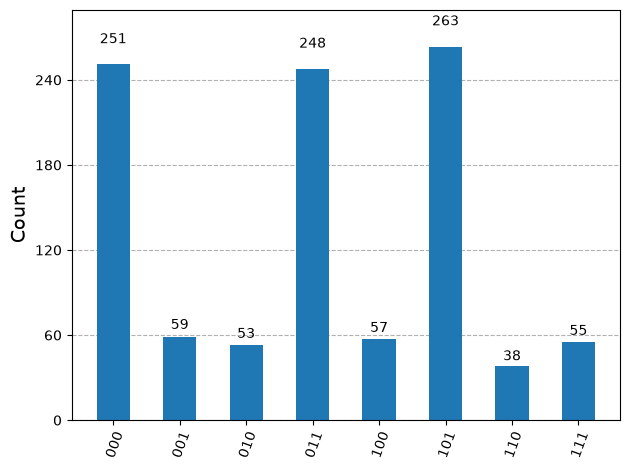

In [13]:
plot_histogram(counts)

### Close IBM i Connection

In [14]:
# Close the SQL job connection
sql_job.close()
print("✓ IBM i connection closed")

✓ IBM i connection closed
